In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Logistic regression

In [2]:
function_values = np.load("Testing results/Logistic regression/function_values.npy", allow_pickle=True)
calculation_times = np.load("Testing results/Logistic regression/calculation_times.npy", allow_pickle=True)
steps = np.load("Testing results/Logistic regression/steps.npy", allow_pickle=True)
Lipschitz_constants = np.load("Testing results/Logistic regression/Lipschitz_constants.npy", allow_pickle=True)

In [3]:
minimum = []
for n in range(3):
    minimum.append(np.min(np.concatenate(function_values[n])))

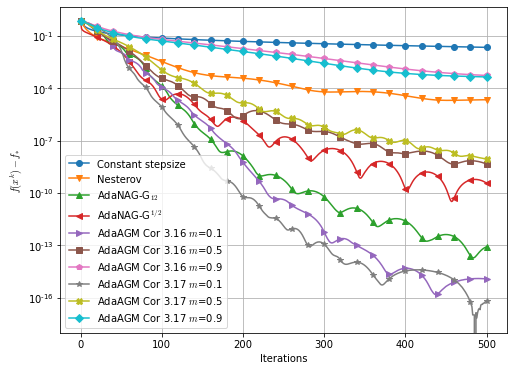

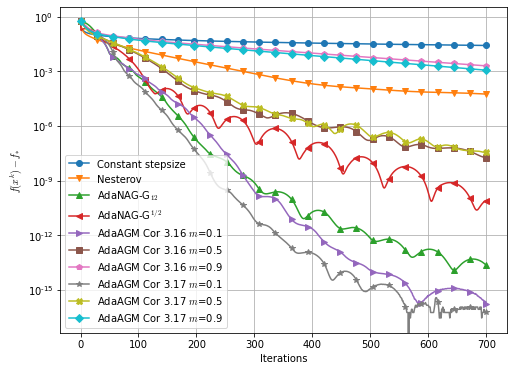

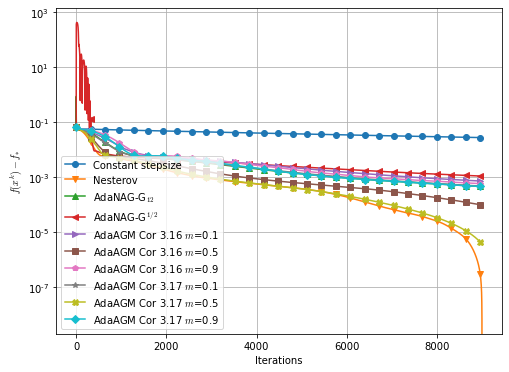

In [4]:
plt.rcParams["mathtext.fontset"] = "cm"
labels = ['Constant stepsize', 'Nesterov', 'AdaNAG-G$_{12}$', 'AdaNAG-G$^{1/2}$', 'AdaAGM Cor 3.16 $m$=0.1', 'AdaAGM Cor 3.16 $m$=0.5', 'AdaAGM Cor 3.16 $m$=0.9', 'AdaAGM Cor 3.17 $m$=0.1', 'AdaAGM Cor 3.17 $m$=0.5', 'AdaAGM Cor 3.17 $m$=0.9']
titles = ['mushrooms', 'w8a', 'covtype']
markers = ['o', 'v', '^', '<', '>', 's', 'p', '*', 'X', 'D'] 
mark_every = [20, 28, 320]
for k in range(3):

    fig, ax = plt.subplots(figsize=(8,6))

    for index, value_sequence in enumerate(function_values[k]):
        ax.plot(
            value_sequence - minimum[k],
            label=labels[index],
            marker=markers[index],
            markevery=mark_every[k]
        )

    ax.set_yscale('log')
    ax.legend()
    ax.set_xlabel('Iterations')
    ax.set_ylabel(r'$f(x^{k}) - f_{*}$')
    ax.grid()

    # save each figure separately
    fig.savefig(
        f"figures/Logistic regression/values_{titles[k]}.pdf",
        bbox_inches="tight"
    )

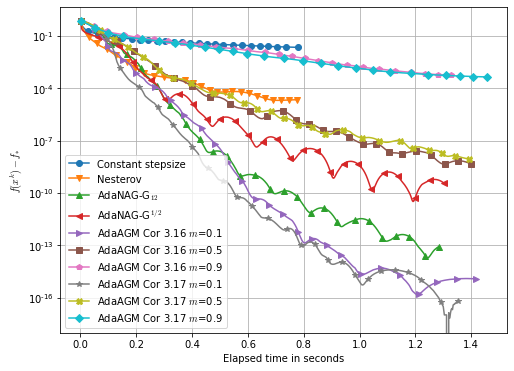

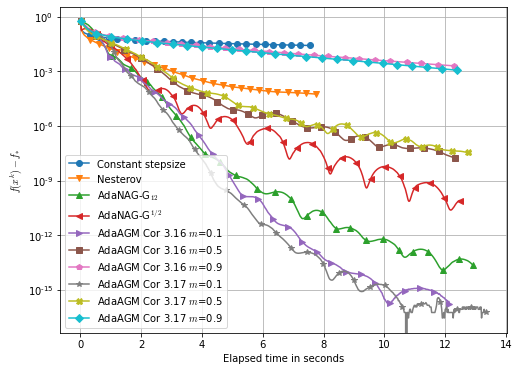

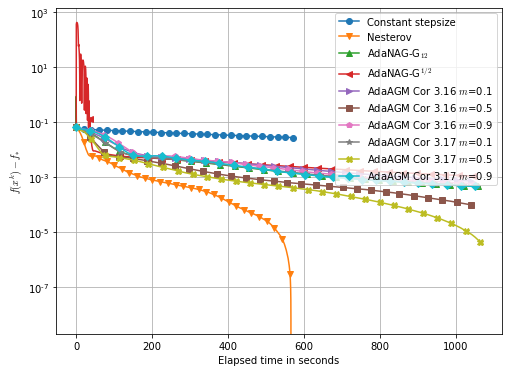

In [5]:
for k in range(3):
    fig, ax = plt.subplots(figsize=(8,6))

    for index, value_sequence in enumerate(function_values[k]):
        ax.plot(
            calculation_times[k][index],
            value_sequence - minimum[k],
            label=labels[index],
            marker=markers[index],
            markevery=mark_every[k]
        )

    ax.set_yscale('log')
    ax.legend()
    ax.set_xlabel('Elapsed time in seconds')
    ax.set_ylabel(r'$f(x^{k}) - f_{*}$')
    ax.grid()

    # save each figure separately
    fig.savefig(
        f"figures/Logistic regression/values_time_{titles[k]}.pdf",
        bbox_inches="tight"
    )

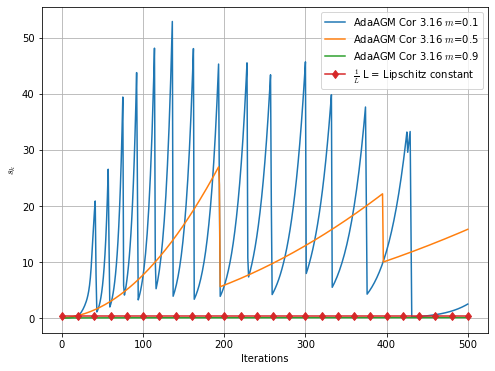

In [7]:
fig, ax = plt.subplots(figsize=(8,6))
which_matrix = 0
which_plots = [4,5,6]
for k in which_plots:
    ax.plot(
    steps[which_matrix][k - 2],
    label=labels[k],
    )
vector = np.empty(len(steps[which_matrix][0]))
vector.fill(1/Lipschitz_constants[which_matrix])
ax.plot(vector, 'd', markevery=mark_every[which_matrix], linestyle='-', label=r'$\frac{1}{L}$ L = Lipschitz constant')
ax.legend()
ax.set_xlabel('Iterations')
ax.set_ylabel(r'$s_k$')
ax.grid()


fig.savefig(
    f"figures/Logistic regression/steps_different_m_values_{titles[which_matrix]}.pdf",
    bbox_inches="tight"
)


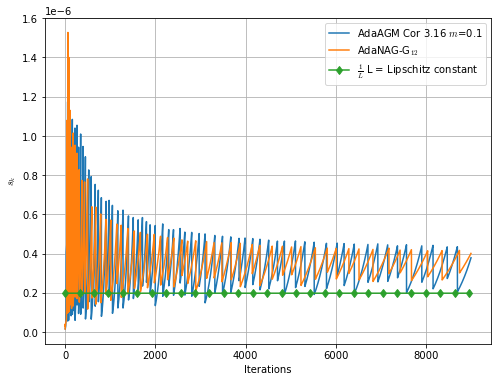

In [8]:
fig, ax = plt.subplots(figsize=(8,6))
which_matrix = 2
which_plots = [4,2]
for k in which_plots:
    if k == 2:
            ax.plot(steps[which_matrix][k - 2][1::], label=labels[k],)
    else:
        ax.plot(steps[which_matrix][k - 2], label=labels[k])
        
vector = np.empty(len(steps[which_matrix][0]))
vector.fill(1/Lipschitz_constants[which_matrix])
ax.plot(vector, 'd', markevery=mark_every[which_matrix], linestyle='-', label=r'$\frac{1}{L}$ L = Lipschitz constant')
ax.legend()
ax.set_xlabel('Iterations')
ax.set_ylabel(r'$s_k$')
ax.grid()


fig.savefig(
    f"figures/Logistic regression/steps_AdaNAG_vs_AdaAGM_{titles[which_matrix]}.pdf",
    bbox_inches="tight"
)


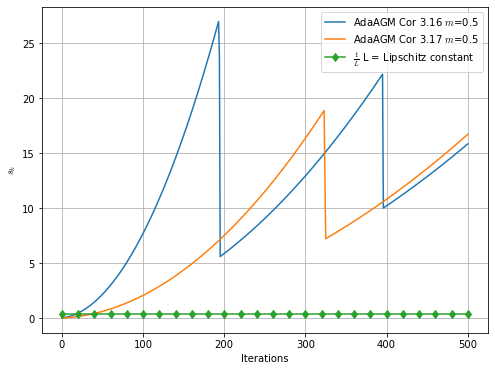

In [10]:
fig, ax = plt.subplots(figsize=(8,6))
which_matrix = 0
which_plots = [5, 8]
for k in which_plots:
    ax.plot(
    steps[which_matrix][k - 2],
    label=labels[k],
    )
vector = np.empty(len(steps[which_matrix][0]))
vector.fill(1/Lipschitz_constants[which_matrix])
ax.plot(vector, 'd', markevery=mark_every[which_matrix], linestyle='-', label=r'$\frac{1}{L}$ L = Lipschitz constant')
ax.legend()
ax.set_xlabel('Iterations')
ax.set_ylabel(r'$s_k$')
ax.grid()


fig.savefig(
    f"figures/Logistic regression/steps_Cor5.5_vs_Cor5.6_{titles[which_matrix]}.pdf",
    bbox_inches="tight"
)


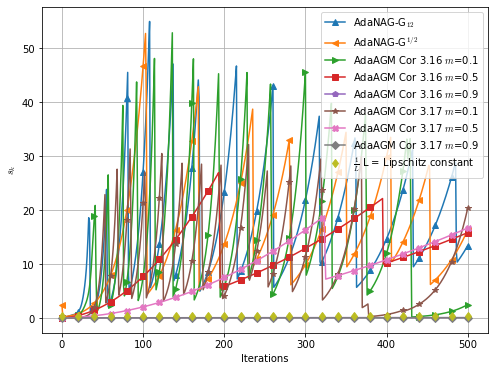

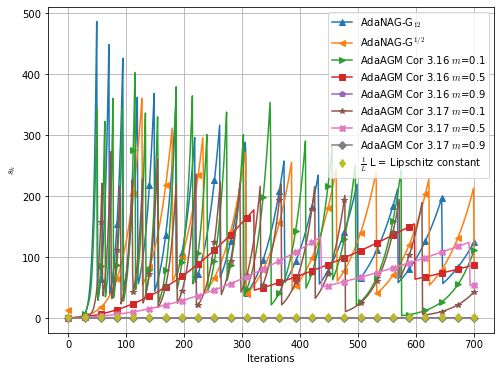

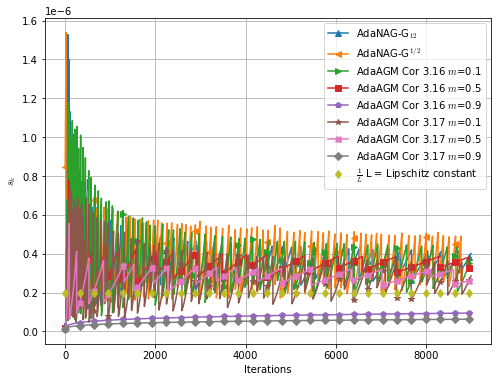

In [11]:
for k in range(3):
    fig, ax = plt.subplots(figsize=(8,6))

    for index, step_sequence in enumerate(steps[k]):
        #first stepsize in these cases too large
        if k == 2 and index == 0:
            ax.plot(step_sequence[1::], label=labels[index+2], marker=markers[index+2], markevery=mark_every[k])
        elif k == 2 and index == 1:
            ax.plot(step_sequence[180::], label=labels[index+2], marker=markers[index+2], markevery=mark_every[k])
        else:
            ax.plot(
                step_sequence,
                label=labels[index+2],
                marker=markers[index+2],
                markevery=mark_every[k]
            )
    vector = np.empty(len(step_sequence))
    vector.fill(1/Lipschitz_constants[k])
    ax.plot(vector, 'd', markevery=mark_every[k], label=r'$\frac{1}{L}$ L = Lipschitz constant')
    ax.legend()
    ax.set_xlabel('Iterations')
    ax.set_ylabel(r'$s_k$')
    ax.grid()
    

# Least squares

In [12]:
function_values = np.load("Testing results/Least squares/function_values.npy", allow_pickle=True)
calculation_times = np.load("Testing results/Least squares/calculation_times.npy", allow_pickle=True)
steps = np.load("Testing results/Least squares/steps.npy", allow_pickle=True)
Lipschitz_constants = np.load("Testing results/Least squares/Lipschitz_constants.npy", allow_pickle=True)

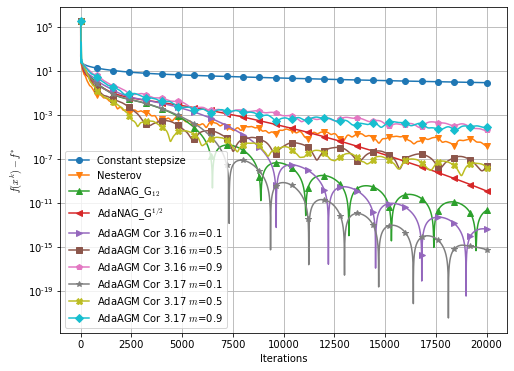

C:\WinPython\WPy64-31050\python-3.10.5.amd64\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


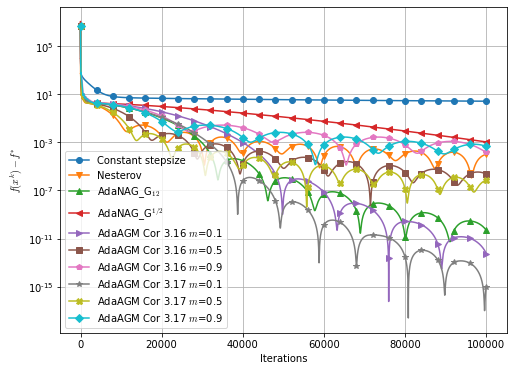

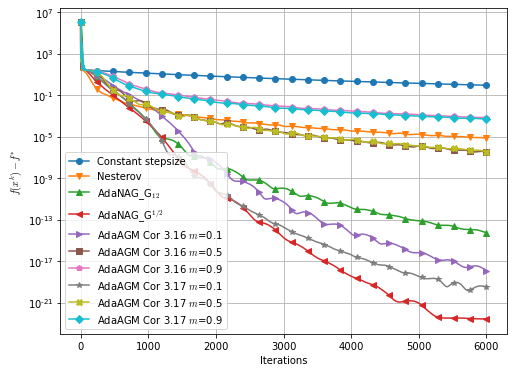

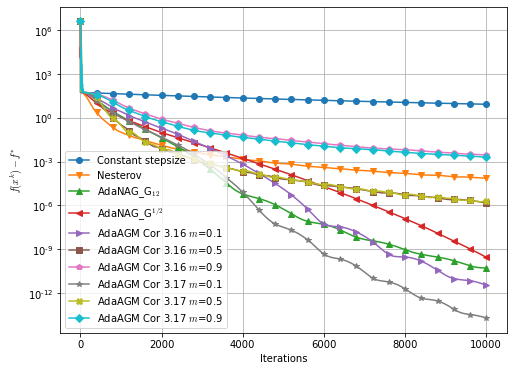

In [13]:
plt.rcParams["mathtext.fontset"] = "cm"
labels = ['Constant stepsize', 'Nesterov', 'AdaNAG_G$_{12}$', 'AdaNAG_G$^{1/2}$', 'AdaAGM Cor 3.16 $m$=0.1', 'AdaAGM Cor 3.16 $m$=0.5', 'AdaAGM Cor 3.16 $m$=0.9', 'AdaAGM Cor 3.17 $m$=0.1', 'AdaAGM Cor 3.17 $m$=0.5', 'AdaAGM Cor 3.17 $m$=0.9']
titles = ['bodyfat', 'cadata', 'random small', 'random large']
markers = ['o', 'v', '^', '<', '>', 's', 'p', '*', 'X', 'D'] 
mark_every = [800, 4000, 240, 400]
for k in range(4):

    fig, ax = plt.subplots(figsize=(8,6))

    for index, value_sequence in enumerate(function_values[k]):
        ax.plot(
            value_sequence,
            label=labels[index],
            marker=markers[index],
            markevery=mark_every[k]
        )

    ax.set_yscale('log')
    ax.legend()
    ax.set_xlabel('Iterations')
    ax.set_ylabel(r'$f(x^{k}) - f^{*}$')
    ax.grid()

    # save each figure separately
    fig.savefig(
        f"figures/Least squares/values_{titles[k]}.pdf",
        bbox_inches="tight"
    )

In [ ]:
for k in range(4):
    fig, ax = plt.subplots(figsize=(8,6))

    for index, value_sequence in enumerate(function_values[k]):
        ax.plot(
            calculation_times[k][index],
            value_sequence,
            label=labels[index],
            marker=markers[index],
            markevery=mark_every[k]
        )

    ax.set_yscale('log')
    ax.legend()
    ax.set_xlabel('Elapsed time in seconds')
    ax.set_ylabel(r'$f(x^{k}) - f^{*}$')
    ax.grid()

    # save each figure separately
    fig.savefig(
        f"figures/Least squares/values_time_{titles[k]}.pdf",
        bbox_inches="tight"
    )

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
which_matrix = 3
which_plots = [4,5,6]
for k in which_plots:
    ax.plot(
    steps[which_matrix][k - 2],
    label=labels[k],
    )
vector = np.empty(len(steps[which_matrix][0]))
vector.fill(1/Lipschitz_constants[which_matrix])
ax.plot(vector, 'd', markevery=mark_every[which_matrix], linestyle='-', label=r'$\frac{1}{L}$ L = Lipschitz constant')
ax.legend()
ax.set_xlabel('Iterations')
ax.set_ylabel(r'$s_k$')
ax.grid()


fig.savefig(
    f"figures/Least squares/steps_different_m_values_{titles[which_matrix]}.pdf"
)


In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
which_matrix = 3
which_plots = [4,2]
for k in which_plots:
    ax.plot(
    steps[which_matrix][k - 2],
    label=labels[k],
    )
vector = np.empty(len(steps[which_matrix][0]))
vector.fill(1/Lipschitz_constants[which_matrix])
ax.plot(vector, 'd', markevery=mark_every[which_matrix], linestyle='-', label=r'$\frac{1}{L}$ L = Lipschitz constant')
ax.legend()
ax.set_xlabel('Iterations')
ax.set_ylabel(r'$s_k$')
ax.grid()


fig.savefig(
    f"figures/Least squares/steps_AdaNAG_vs_AdaAGM_{titles[which_matrix]}.pdf"
)


In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
which_matrix = 1
which_plots = [5, 8]
for k in which_plots:
    ax.plot(
    steps[which_matrix][k - 2],
    label=labels[k],
    )
vector = np.empty(len(steps[which_matrix][0]))
vector.fill(1/Lipschitz_constants[which_matrix])
ax.plot(vector, 'd', markevery=mark_every[which_matrix], linestyle='-', label=r'$\frac{1}{L}$ L = Lipschitz constant')
ax.legend()
ax.set_xlabel('Iterations')
ax.set_ylabel(r'$s_k$')
ax.grid()


fig.savefig(
    f"figures/Least squares/steps_Cor5.5_vs_Cor5.6_{titles[which_matrix]}.pdf"
)


In [ ]:
for k in range(4):
    fig, ax = plt.subplots(figsize=(8,6))

    for index, step_sequence in enumerate(steps[k]):
        ax.plot(
            step_sequence,
            label=labels[index+2],
            marker=markers[index+2],
            markevery=mark_every[k]
        )
    vector = np.empty(len(step_sequence))
    vector.fill(1/Lipschitz_constants[k])
    ax.plot(vector, 'd', markevery=mark_every[k], linestyle='-', label=r'$\frac{1}{L}$ L = Lipschitz constant')
    ax.legend()
    ax.set_xlabel('Iterations')
    ax.set_ylabel(r'$s_k$')
    ax.grid()
